# Olist平台用户评价归因分析：从“运费假设”到“超时预警”

## 一、业务背景
平台数据显示，在已完成交付的订单中，**1-2分差评占比约为12.77%**。
业务方初步推测，可能是“运费过高”导致了用户不满，但这一假设尚未经过数据验证。

## 二、分析目标
基于真实订单数据，排查导致差评的核心因素，并基于数据结论提出落地的运营优化方向。

## 数据提取（SQL部分）

原始数据分散在 4 张相互关联的表中，且在导入时遇到时间格式不兼容的问题。在 DataGrip 中，我的处理逻辑如下：

1. **数据导入（建表策略）**：因为 CSV 文件的时间格式包含斜杠（如 2017/10/02），直接导入 `DATETIME` 字段会报错，因此建表时我将所有时间字段统一设为 `VARCHAR(50)` 接收。等数据进入 Pandas 后，再使用 `to_datetime()` 统一转换为标准时间格式。
2. **分步聚合（防数据膨胀）**：因为一个订单包含多件商品（订单明细表一对多），且可能有多次评价（评价表一对多），如果直接关联会导致数据成倍膨胀。所以我使用了 CTE（`WITH` 子句）分步处理：
   - `order_items` 聚合：按 `order_id` 分组，用 `SUM()` 计算每个订单的总商品金额与总运费。
   - `order_reviews` 聚合：按 `order_id` 分组，用 `AVG()` 计算每个订单的平均评分。
3. **多表关联**：最后通过 `JOIN` 将聚合后的订单明细、评价，以及客户表、订单表（获取下单时间与预计送达时间）拼接成一张宽表，并导出为 CSV 供 Python 进一步分析。

In [1]:
# 数据清洗与特征工程
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family']='SimHei'
rcParams['axes.unicode_minus']=False

df=pd.read_csv(r'C:\Users\H\Olist_subject.csv')
## 剔除不含送达时间的订单
df=df.dropna(subset='order_delivered_customer_date')
## 转换时间格式
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date']=pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date']=pd.to_datetime(df['order_estimated_delivery_date'])
## 计算核心衍生指标
df['运费占比']=df['total_freight']/(df['total_price']+df['total_freight'])
df['运输天数']=(df['order_delivered_customer_date']-df['order_purchase_timestamp']).dt.days
df['超时天数']=(df['order_delivered_customer_date']-df['order_estimated_delivery_date']).dt.days
## 剔除异常值
df=df[df['运输天数']>0]
df['运费占比']=df['运费占比'].astype(float)
df=df[df['运费占比']<=1]
## 切分业务分箱
df['送达情况']=pd.cut(df['超时天数'],bins=[-1000,0,3,7,15,1000],labels=['准时','超时1-3天','超时3-7天','超时7-15天','超时15天以上'])
df['运费档位']=pd.cut(df['运费占比'],bins=[-1,0,0.1,0.3,1],labels=['免邮','0-10%','10-30%','30%以上'])

## 分析一：推翻初始假设——运费并非元凶

**假设验证**：业务方初步推测“运费过高”是导致差评的核心原因。
为了验证这个假设，我将“运费占比”划分为四档（免邮、0-10%、10-30%、30%以上），对比不同档位下用户的平均评分。

如果高运费真的是差评诱因，那么随着运费档位升高，平均评分应该出现明显下滑。

不同运费档位的平均评分
运费档位
免邮        4.39
0-10%     4.20
10-30%    4.16
30%以上     4.11
Name: review_score, dtype: float64


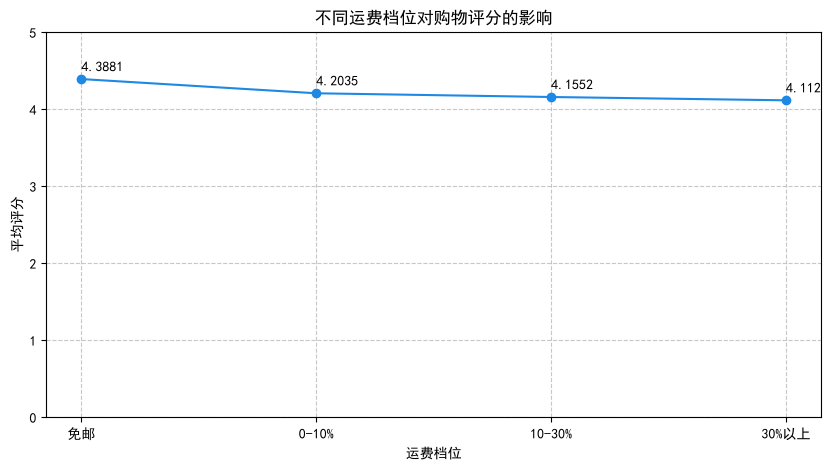

In [2]:
# 按运费档位分组计算平均评分
plot_data1=df.groupby('运费档位')['review_score'].mean()
print('不同运费档位的平均评分')
print(plot_data1.round(2))

plt.figure(figsize=(10,5))
plt.plot(plot_data1.index,plot_data1.values,label='平均评分',marker='o',color='#1E88E5')
plt.title('不同运费档位对购物评分的影响')
plt.xlabel('运费档位')
plt.ylabel('平均评分')
plt.grid(linestyle='--',alpha=0.7)
plt.ylim(0,5)
for x,y in zip(plot_data1.index,plot_data1.values):
    plt.text(x,y+0.1,str(y.round(4)))
plt.show()

## 分析二：锁定真凶——物流超时才是核心杀手

**深度排查**：分析一的数据证明了运费对评分影响微乎其微，这说明真凶藏在别处。
我从时间维度切入，计算“实际送达时间”与“平台预计送达时间”的差值（超时天数），并将超时天数划分为5个业务档位（准时、超时1-3天、超时3-7天、超时7-15天、超时15天以上）。

此步的目的是：精准定位在哪个超时区间，用户的差评率会发生断崖式跃升，从而找到用户心理的“生死线”。



运费档位       免邮  0-10%  10-30%  30%以上
送达情况                               
准时       4.43   4.34    4.29   4.25
超时1-3天   4.00   3.39    3.25   3.33
超时3-7天   2.00   2.06    2.14   2.06
超时7-15天  2.75   1.57    1.68   1.74
超时15天以上  0.00   1.85    1.71   1.69
--------------------------------------------------
is_bad_review       0       1
送达情况                         
准时             0.9076  0.0924
超时1-3天         0.6782  0.3218
超时3-7天         0.3244  0.6756
超时7-15天        0.2010  0.7990
超时15天以上        0.2186  0.7814
--------------------------------------------------
送达情况
准时         0.09
超时1-3天     0.32
超时3-7天     0.68
超时7-15天    0.80
超时15天以上    0.78
Name: is_bad_review, dtype: float64


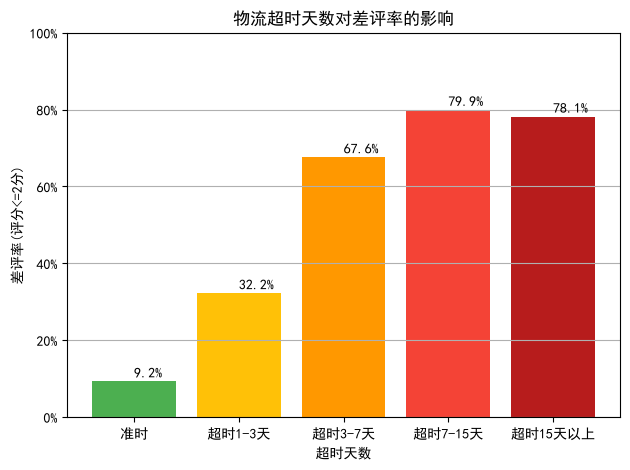

In [3]:
# 交叉透视：计算不同“送达情况”和“运费档位”下的评分（fillna（0）防止有的格子没数据）
print(pd.crosstab(df['送达情况'],df['运费档位'],values=df['review_score'],aggfunc='mean').fillna(0).round(2))
print('-'*50)
# 打差评标签：将评分<=2分订单标记为1（差评）3-5分的标记为0（好评）
df['is_bad_review']=(df['review_score']<=2).astype(int)
# 交叉透视：计算不同“送达情况”下的差评率
print(pd.crosstab(df['送达情况'],df['is_bad_review'],normalize='index').round(4))
print('-'*50)
# 按超时情况分组，求差评率均值
plot_data2=df.groupby('送达情况')['is_bad_review'].mean()
print(plot_data2.round(2))

colors=['#4CAF50','#FFC107','#FF9800','#F44336','#B71C1C']
plt.bar(plot_data2.index,plot_data2.values,color=colors)
plt.title('物流超时天数对差评率的影响')
plt.xlabel('超时天数')
plt.ylabel('差评率(评分<=2分)')
plt.grid(axis='y')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_:f'{x:.0%}'))
for x,y in zip(plot_data2.index,plot_data2.values):
    plt.text(x,y+0.01,f'{y:.1%}')
plt.tight_layout()
plt.show()

## 核心结论与业务建议

**核心结论**：
1. **推翻初始假设**：运费对评分影响极小，极差仅约0.27分。业务方之前关于“运费高导致差评”的猜测被数据证伪。
2. **锁定真凶**：物流超时是引发差评的核心因素。准时送达差评率仅为9.2%；一旦超时超过3天，差评率断崖式飙升至67.6%；超时7天以上高达79.9%。
3. **找到生死线**：“超时3天”是用户心理的绝对红线。

**业务建议**：
1. **资源重配**：既然数据证明运费不是差评元凶，建议业务方不必过度聚焦运费优化，应将核心精力转向物流履约保障。
2. **建立预警机制**：将“超时3天”设为红线，当系统预测订单可能超时2天时，自动触发客服干预并前置发放补偿券，将差评扼杀在摇篮中。
3. **物流考核**：对超时率高于行业均值的物流承运商进行末位淘汰。